# Manos a la obra

Este notebook da una rápida presentación de cómo usar los conceptos básicos de Brightway:

+ proyectos (Project)
+ Actividades (Activity)
+ Intercambios (Exchanges)

## Importar las librerías necesarias

In [ ]:
import bw2calc as bc
import bw2data as bd
import bw2io as bi

## Crear un proyecto que contenga la base de datos de la biosfera de ecoinvent 3.10

In [ ]:
bi.remote.install_project(
    "ecoinvent-3.10-biosphere", "peru25-project", overwrite_existing=True
)

In [ ]:
bd.projects.current

In [ ]:
bd.projects.set_current("peru25-project")

In [ ]:
bd.databases

## Crear la base de datos para nuestra cadena de suministro

In [ ]:
# restart the database for quick and easy re-use
if "bike" in bd.databases:
    del bd.databases["bike"]
# if biosphere3 database is not in the project yet. This is automatically verified
# it's safe to do this call in any case

In [ ]:
db = bd.Database("bike")
db.register()

## Crear las actividades de nuestra base de datos ejemplo

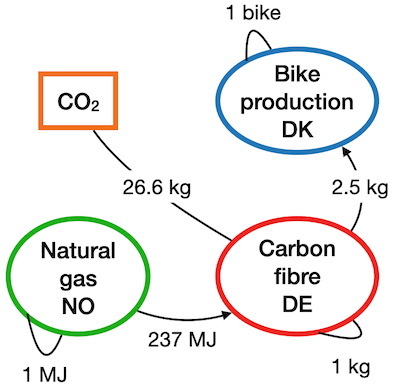


In [ ]:
# First activity: the bike
data = {"code": "bike", "name": "bike production", "location": "DK", "unit": "bike"}
bike = db.new_node(**data)
bike.save()


# First input
data = {"code": "ng", "name": "natural gas production", "location": "NO", "unit": "MJ"}

ng = db.new_node(**data)
ng.save()

# Second input
data = {"code": "cf", "name": "carbon fibre production", "location": "DE", "unit": "kg"}

cf = db.new_node(**data)
cf.save()

# We add the exchange to the bike activity, from the carbon fiber prod

bike.new_edge(amount=2.5, type="technosphere", input=cf).save()

In [ ]:
# Verify by printing the exchanges of the bike
a_bike = db.get("bike")
for e in a_bike.exchanges():
    print(e)


# Add another exchange to the carbon fiber production
cf.new_edge(
    amount=237.3,  # plus 58 kWh of electricity, in ecoinvent 3.8
    uncertainty_type=5,
    minimum=200,
    maximum=300,
    type="technosphere",
    input=ng,
).save()

## Encontrar el método de impacto deseado

In [ ]:
# Let's find the co2 emission to air from the biosphere that is used
# in the EF V3.0 method:

# This assumes "namespaced" methods in the project
random_m = bd.methods.random()
if len(random_m) == 4:
    # we have namespaced methods
    ef_cc_key = (
        "ecoinvent-3.10",
        "EF v3.1",
        "climate change",
        "global warming potential (GWP100)",
    )
else:
    ef_cc_key = ("EF v3.1", "climate change", "global warming potential (GWP100)")
ef_cc_method = bd.Method(ef_cc_key)
ef_cc_method.metadata

In [ ]:
# Here are the actual characterization factors of the method
cfs = ef_cc_method.load()

In [ ]:
bio_db = bd.Database("biosphere3")
for a_cf in cfs:
    # a_cf: under bw25, this would be a tuple with flow id and cf
    flow = bd.get_activity(a_cf[0])
    if "Carbon dioxide, fossil" in flow["name"] and ("air",) == flow["categories"]:
        # print(flow)
        # print(flow_key)
        break
print(f"Found flow: {flow}")


cf.new_edge(
    amount=26.6,
    uncertainty_type=5,
    minimum=26,
    maximum=27.2,
    type="biosphere",
    input=flow,
).save()

## LCIA

In [ ]:
# Now we can do a regular LCA, with an actual lcia method

# printing the contribution analysis
import bw2analyzer as bwa

bwa.print_recursive_supply_chain(bike)

In [ ]:
lca = bc.LCA({bike: 1}, ef_cc_key)

lca.lci()
lca.lcia()
lca.score

In [ ]:
ef_cc_m = bd.Method(ef_cc_key)
print(f"{ef_cc_m} - score for: {bike} => {lca.score} {ef_cc_m.metadata['unit']}")

## pseudo análisis de contribuciones

In [ ]:
bwa.print_recursive_calculation(bike, ef_cc_key)